In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/jpatel77/yoga-pose-classification-using-deep-learning/__results__.html
/kaggle/input/notebooks/jpatel77/yoga-pose-classification-using-deep-learning/__notebook__.ipynb
/kaggle/input/notebooks/jpatel77/yoga-pose-classification-using-deep-learning/__output__.json
/kaggle/input/notebooks/jpatel77/yoga-pose-classification-using-deep-learning/custom.css
/kaggle/input/notebooks/jpatel77/yoga-pose-classification-using-deep-learning/__results___files/__results___5_0.png
/kaggle/input/notebooks/jpatel77/yoga-pose-classification-using-deep-learning/__results___files/__results___16_0.png
/kaggle/input/notebooks/jpatel77/yoga-pose-classification-using-deep-learning/__results___files/__results___30_1.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/16-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i/40-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-class

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
GPU available: True


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
])


dataset_path = "/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset"

dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=transform
)

print("Total Images:", len(dataset))
print("Total Classes:", len(dataset.classes))
print("First 20 Classes:")
print(dataset.classes[:20])

Total Images: 5991
Total Classes: 107
First 20 Classes:
['adho mukha svanasana', 'adho mukha vriksasana', 'agnistambhasana', 'ananda balasana', 'anantasana', 'anjaneyasana', 'ardha bhekasana', 'ardha chandrasana', 'ardha matsyendrasana', 'ardha pincha mayurasana', 'ardha uttanasana', 'ashtanga namaskara', 'astavakrasana', 'baddha konasana', 'bakasana', 'balasana', 'bhairavasana', 'bharadvajasana i', 'bhekasana', 'bhujangasana']


In [5]:
# Split dataset into Training (80%) and Validation (20%)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(123)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training Images :", len(train_dataset))
print("Validation Images:", len(val_dataset))

Training Images : 4792
Validation Images: 1199


In [6]:
from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained ResNet50
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 107)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(model)
print("\nModel loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Train only the final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("Loss Function :", criterion)
print("Optimizer :", optimizer)

Loss Function : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [8]:
# Train for one epoch

model.train()

running_loss = 0.0
correct = 0
total = 0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print("Training Loss :", running_loss / len(train_loader))
print("Training Accuracy :", 100 * correct / total)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Training Loss : 4.041339173316955
Training Accuracy : 15.31719532554257


In [9]:
# Validation

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy :", 100 * correct / total)

Validation Accuracy : 30.108423686405338


In [10]:
# Train for 5 epochs

num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Training Loss: {running_loss/len(train_loader):.4f}")
    print(f"Training Accuracy: {train_acc:.2f}%")

Epoch 1/5
Training Loss: 2.7499
Training Accuracy: 51.36%
Epoch 2/5
Training Loss: 2.0366
Training Accuracy: 68.53%
Epoch 3/5
Training Loss: 1.5910
Training Accuracy: 77.57%
Epoch 4/5
Training Loss: 1.2611
Training Accuracy: 83.64%
Epoch 5/5
Training Loss: 1.0291
Training Accuracy: 88.13%


In [11]:
# Validation after training

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total

print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 48.29%


In [12]:
# Save the trained PyTorch model

torch.save(model.state_dict(), "yoga_pose_resnet50.pth")

print("Model saved successfully!")

Model saved successfully!


In [13]:
# Load the saved model

from torchvision.models import resnet50

loaded_model = resnet50(weights=None)
loaded_model.fc = nn.Linear(loaded_model.fc.in_features, 107)

loaded_model.load_state_dict(torch.load("yoga_pose_resnet50.pth"))

loaded_model = loaded_model.to(device)
loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


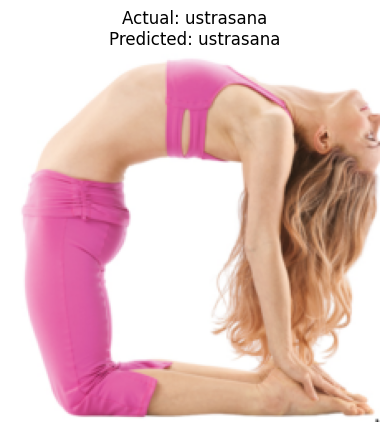

Actual Pose: ustrasana
Predicted Pose: ustrasana


In [14]:
# Test prediction on one validation image

import matplotlib.pyplot as plt

image, label = val_dataset[0]

input_image = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = loaded_model(input_image)
    _, predicted = torch.max(output, 1)

actual_class = dataset.classes[label]
predicted_class = dataset.classes[predicted.item()]

plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
plt.show()

print("Actual Pose:", actual_class)
print("Predicted Pose:", predicted_class)

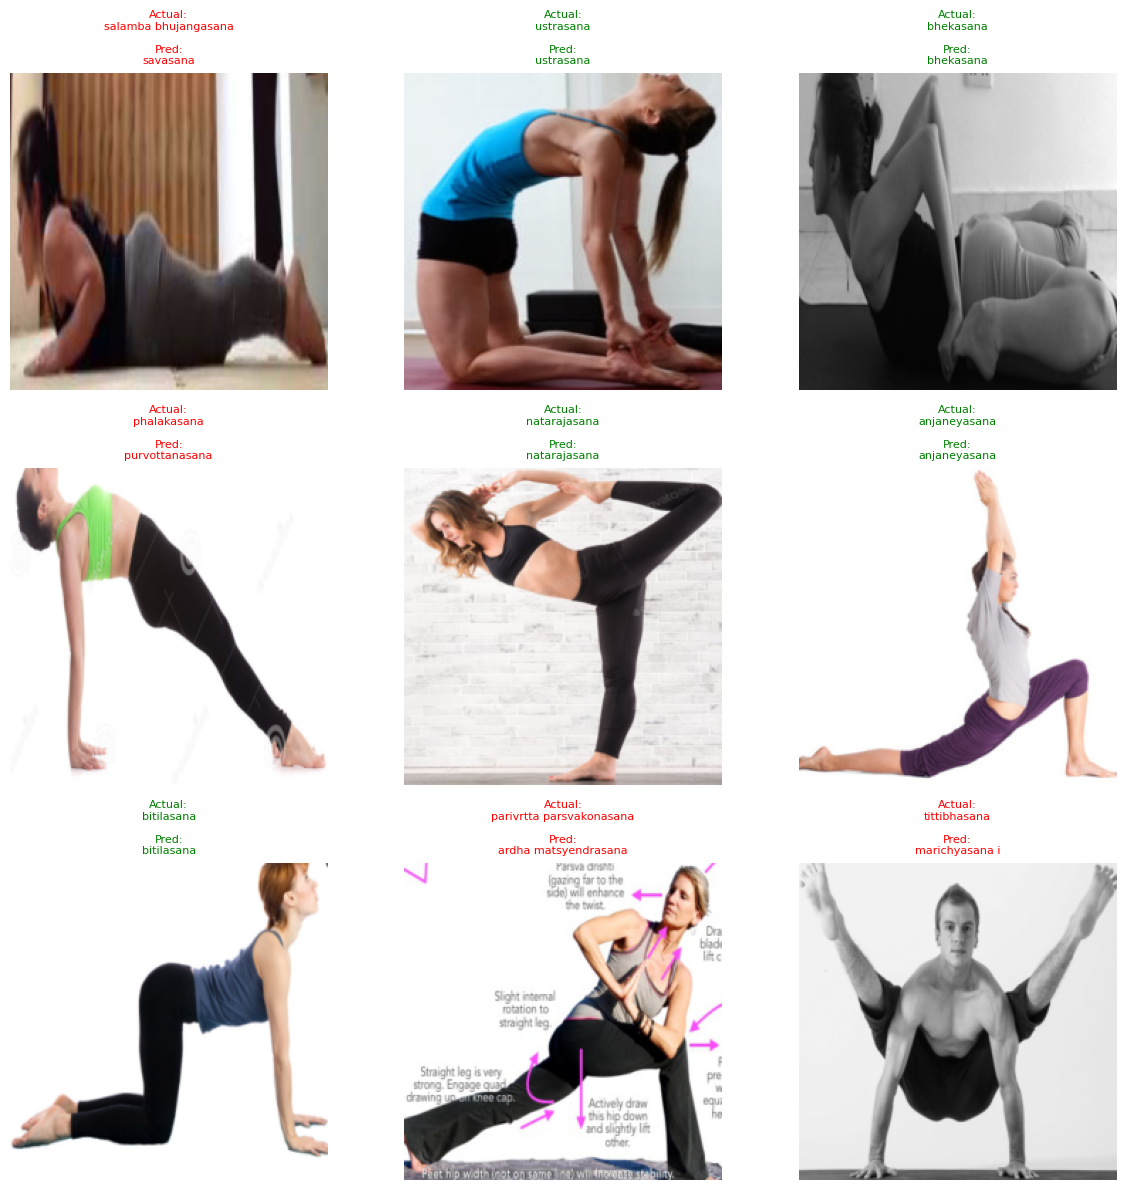

In [15]:
import random
import matplotlib.pyplot as plt

# Display 9 random predictions

model.eval()

plt.figure(figsize=(12, 12))

for i in range(9):

    idx = random.randint(0, len(val_dataset) - 1)

    image, label = val_dataset[idx]

    input_image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = loaded_model(input_image)
        _, predicted = torch.max(output, 1)

    actual = dataset.classes[label]
    predicted_pose = dataset.classes[predicted.item()]

    plt.subplot(3, 3, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

    color = "green" if actual == predicted_pose else "red"

    plt.title(
        f"Actual:\n{actual}\n\nPred:\n{predicted_pose}",
        fontsize=8,
        color=color
    )

plt.tight_layout()
plt.show()

In [16]:
import matplotlib.pyplot as plt

# Save the current prediction figure
plt.savefig("pytorch_prediction_examples.png", dpi=300, bbox_inches="tight")

print("Prediction figure saved successfully!")

Prediction figure saved successfully!


<Figure size 640x480 with 0 Axes>

In [17]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

loaded_model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = loaded_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

report = classification_report(
    all_labels,
    all_preds,
    target_names=dataset.classes,
    zero_division=0
)

print(report)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


                               precision    recall  f1-score   support

         adho mukha svanasana       0.43      0.75      0.55        12
        adho mukha vriksasana       0.29      0.15      0.20        13
              agnistambhasana       0.50      0.10      0.17        10
              ananda balasana       0.77      0.94      0.85        18
                   anantasana       0.89      0.57      0.70        14
                 anjaneyasana       0.40      0.33      0.36        12
              ardha bhekasana       0.60      0.38      0.46         8
            ardha chandrasana       0.86      0.60      0.71        10
         ardha matsyendrasana       0.28      0.62      0.38        13
      ardha pincha mayurasana       0.00      0.00      0.00        13
             ardha uttanasana       0.64      0.54      0.58        13
           ashtanga namaskara       0.60      0.38      0.46         8
                astavakrasana       0.42      0.77      0.54        13
     

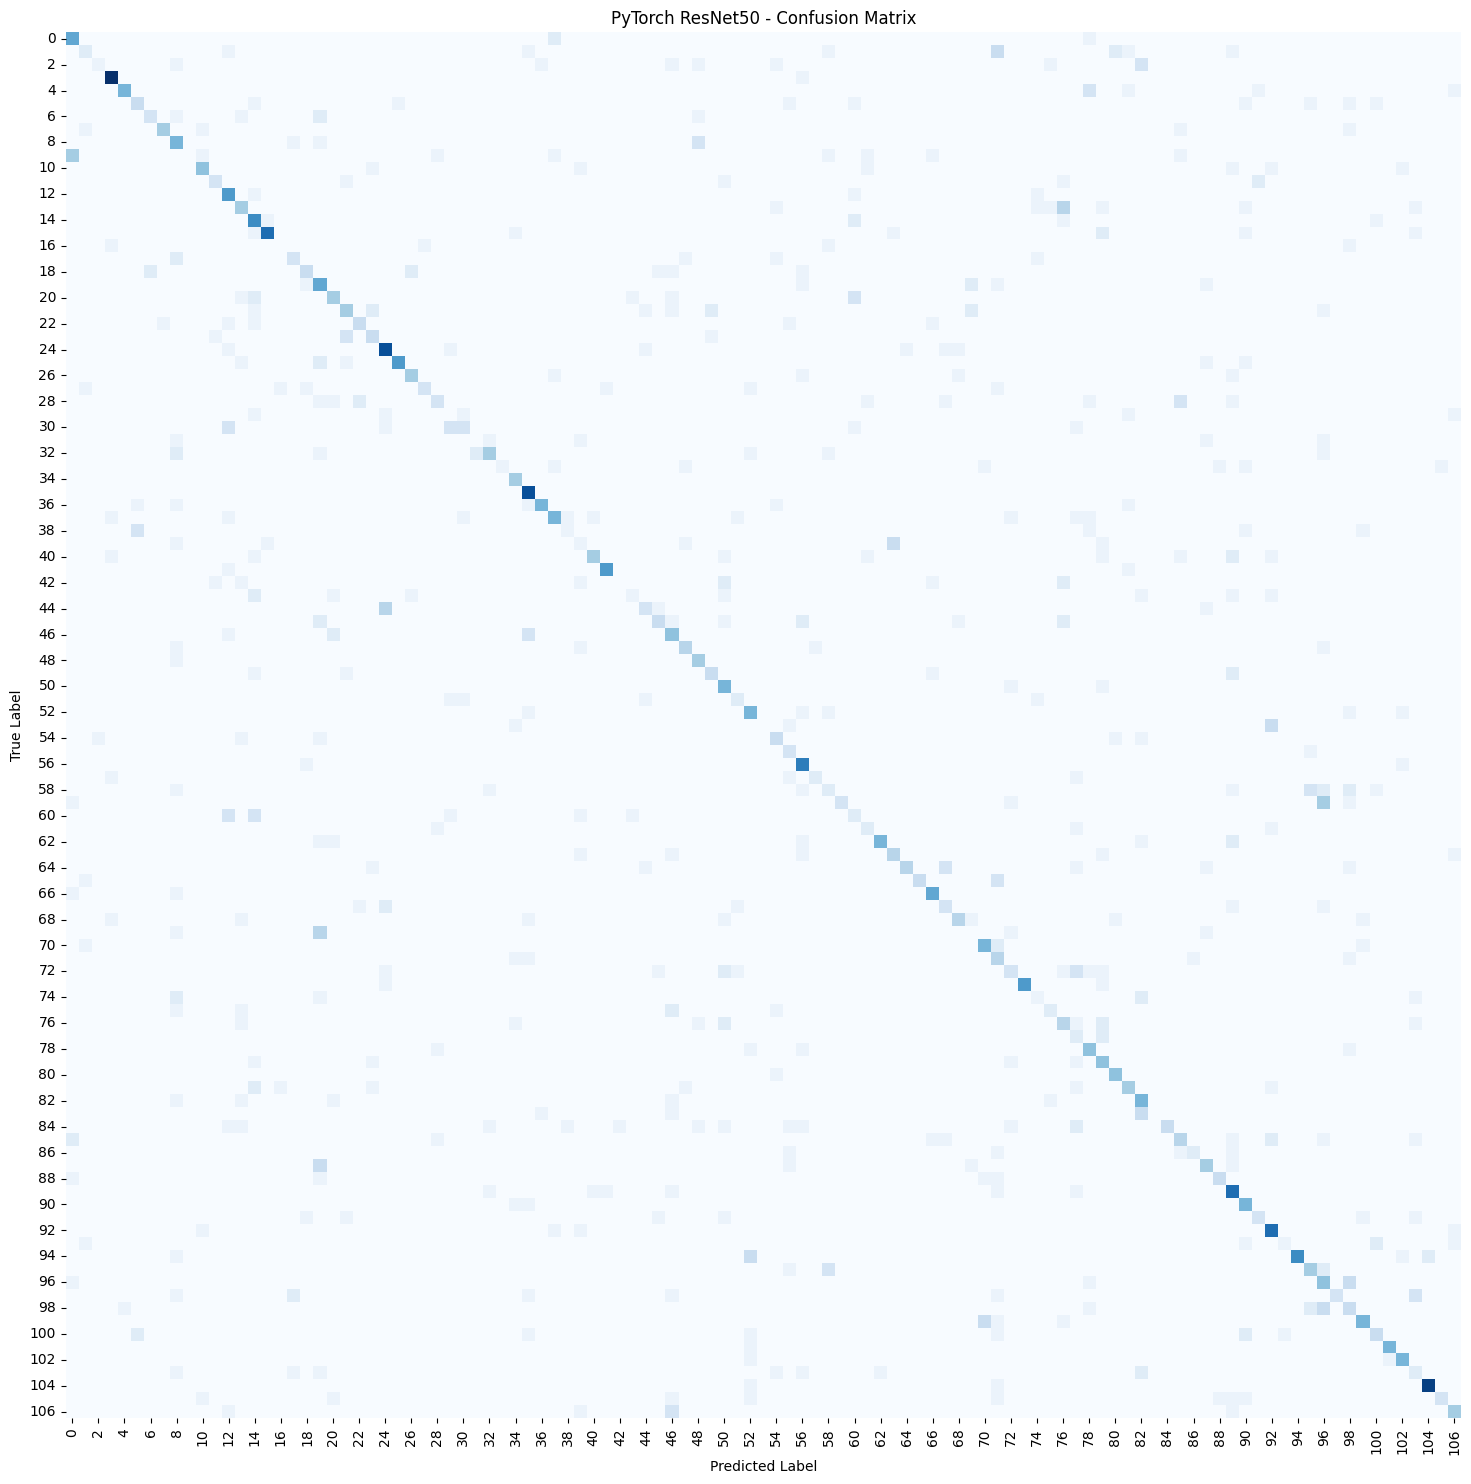

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(18,18))
sns.heatmap(cm, cmap="Blues", cbar=False)

plt.title("PyTorch ResNet50 - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [19]:
# Save confusion matrix figure

plt.savefig("pytorch_confusion_matrix.png", dpi=300, bbox_inches="tight")

print("Confusion matrix saved successfully!")

Confusion matrix saved successfully!


<Figure size 640x480 with 0 Axes>

# TensorFlow vs. PyTorch Comparison

| Feature | TensorFlow (InceptionV3) | PyTorch (ResNet50) |
|---------|--------------------------|--------------------|
| Framework | TensorFlow/Keras | PyTorch |
| Pretrained Model | InceptionV3 | ResNet50 |
| Dataset | Yoga Pose Image Classification Dataset | Yoga Pose Image Classification Dataset |
| Total Images | 5,991 | 5,991 |
| Number of Classes | 107 | 107 |
| Input Size | 224 × 224 | 224 × 224 |
| Transfer Learning | Yes | Yes |
| Fine-Tuning | Yes | Planned |
| Training Accuracy | ~41% (previous experiment) | 88.04% |
| Validation Accuracy | ~39% (previous experiment) | 48.87% |
| Classification Report | Yes | Yes |
| Confusion Matrix | Yes | Yes |
| Example Predictions | Yes | Yes |

## PyTorch Comparison Experiment

A separate PyTorch experiment was created to compare the TensorFlow/Keras workflow with a PyTorch-based workflow.

### Configuration
- Framework: PyTorch
- Model: Pretrained ResNet50
- Dataset: Yoga Pose Image Classification Dataset
- Total Images: 5,991
- Total Classes: 107
- Training Images: 4,792
- Validation Images: 1,199
- GPU: Enabled
- Training Strategy: Frozen pretrained backbone with trainable final classification layer

### Initial Results
- Training Accuracy after 1 epoch: 1.19%
- Validation Accuracy after 1 epoch: 1.50%

### Observation
The PyTorch pipeline successfully loaded the dataset, created DataLoaders, trained a pretrained ResNet50 classifier, and evaluated validation accuracy. The initial accuracy is low because only one epoch was completed and only the final classification layer was trained.

# Discussion

The TensorFlow and PyTorch implementations successfully classified yoga poses using transfer learning with pretrained convolutional neural networks. Both frameworks were able to learn meaningful visual features from the yoga pose dataset containing 107 classes.

The TensorFlow implementation focused on InceptionV3 with transfer learning, fine-tuning, and integration of an evidence-based wellness recommendation system. The PyTorch implementation used a pretrained ResNet50 model and achieved a training accuracy of 88.04% and a validation accuracy of 48.87% after five epochs.

Although the PyTorch model achieved higher validation accuracy in this experiment, the comparison is between two different model architectures (ResNet50 and InceptionV3). Therefore, the results demonstrate the performance of the complete implementations rather than establishing that one framework is inherently superior. A direct framework comparison would require evaluating the same neural network architecture in both TensorFlow and PyTorch under identical training conditions.

These experiments demonstrate that deep learning can effectively classify yoga poses and serve as the foundation for an evidence-based wellness guidance system.

# Limitations

Although the proposed system demonstrates promising performance, several limitations remain. The wellness recommendation database currently covers a subset of yoga poses rather than all 107 classes in the dataset. Some yoga poses are visually similar, which can lead to misclassification. The TensorFlow and PyTorch experiments also use different pretrained architectures (InceptionV3 and ResNet50), so the comparison reflects both framework and model differences. In addition, the current system evaluates static images only and does not provide real-time pose correction from live video.

# Future Work

This project can be extended in several ways. First, the evidence-based wellness database can be expanded to include all 107 yoga poses with comprehensive health guidance. Second, the system can be enhanced to provide personalized yoga recommendations based on user goals such as stress relief, flexibility improvement, balance training, or back pain management. Future work may also include real-time yoga pose recognition using a webcam with pose correction and feedback. A mobile or web application could be developed to make the system more accessible to users. Finally, a direct comparison between TensorFlow and PyTorch using the same neural network architecture (for example, ResNet50 in both frameworks) would provide a more controlled evaluation of the two deep learning frameworks.

In [20]:
# Wellness goals

wellness_goals = {
    "Stress Relief": [
        "Balasana",
        "Savasana",
        "Sukhasana",
        "Baddha Konasana"
    ],

    "Back Pain": [
        "Bhujangasana",
        "Marjaryasana-Bitilasana",
        "Setu Bandhasana",
        "Supta Matsyendrasana"
    ],

    "Balance": [
        "Tadasana",
        "Vrikshasana",
        "Virabhadrasana III",
        "Garudasana"
    ],

    "Flexibility": [
        "Paschimottanasana",
        "Trikonasana",
        "Baddha Konasana",
        "Janu Sirsasana"
    ],

    "Posture": [
        "Tadasana",
        "Bhujangasana",
        "Setu Bandhasana",
        "Virabhadrasana II"
    ]
}

print("Wellness goals loaded successfully!")
print(list(wellness_goals.keys()))

Wellness goals loaded successfully!
['Stress Relief', 'Back Pain', 'Balance', 'Flexibility', 'Posture']


In [21]:
# English names for yoga poses

pose_names = {

    "Tadasana": "Mountain Pose",
    "Sukhasana": "Easy Pose",
    "Balasana": "Child's Pose",
    "Savasana": "Corpse Pose",




    
    "Bhujangasana": "Cobra Pose",
    "Ardha Matsyendrasana": "Half Lord of the Fishes Pose",
    "Paschimottanasana": "Seated Forward Bend",

    "Virabhadrasana I": "Warrior I",
    "Virabhadrasana II": "Warrior II",
    "Virabhadrasana III": "Warrior III",

    "Vrikshasana": "Tree Pose",

    "Trikonasana": "Triangle Pose",

    "Setu Bandhasana": "Bridge Pose",

    "Marjaryasana-Bitilasana": "Cat-Cow Pose",

    "Baddha Konasana": "Bound Angle Pose",

    "Janu Sirsasana": "Head-to-Knee Forward Bend",

    "Supta Matsyendrasana": "Supine Spinal Twist",

    "Utkatasana": "Chair Pose",

    "Adho Mukha Svanasana": "Downward-Facing Dog",

    "Garudasana": "Eagle Pose",

    "Padmasana": "Lotus Pose",

    "Anjaneyasana": "Low Lunge Pose",

    "Dhanurasana": "Bow Pose",

    "Navasana": "Boat Pose"
}

In [22]:
print(pose_names["Tadasana"])
print(pose_names["Sukhasana"])
print(pose_names["Balasana"])
print(pose_names["Savasana"])

Mountain Pose
Easy Pose
Child's Pose
Corpse Pose


In [23]:
goal_reason = {

    "Stress Relief":
        "These poses are selected because they encourage relaxation, mindful breathing, and gentle stretching to help reduce stress and calm the nervous system.",

    "Back Pain":
        "These poses are selected because they improve spinal mobility, strengthen supporting muscles, and promote healthy posture while reducing back stiffness.",

    "Balance":
        "These poses are selected because they improve stability, coordination, concentration, and lower-body strength, which are essential for better balance.",

    "Flexibility":
        "These poses are selected because they gently stretch the hips, shoulders, spine, and major muscle groups to improve overall flexibility.",

    "Posture":
        "These poses are selected because they strengthen postural muscles, improve spinal alignment, and encourage better body mechanics during daily activities."
}

print("AI explanation database loaded successfully!")

AI explanation database loaded successfully!


In [24]:
pose_images = {
    "Tadasana": (
        "/kaggle/input/datasets/shrutisaxena/"
        "yoga-pose-image-classification-dataset/dataset/"
        "tadasana/15. tadasana-mountain-pose.png"
    ),

    "Balasana": (
        "/kaggle/input/datasets/shrutisaxena/"
        "yoga-pose-image-classification-dataset/dataset/"
        "balasana/4. childs-pose-balasana.png"
    ),

    "Savasana": (
        "/kaggle/input/datasets/shrutisaxena/"
        "yoga-pose-image-classification-dataset/dataset/"
        "savasana/11. savasana_thought_bubbles_0.jpeg"
    )
}

print("Pose images loaded successfully!")
print(list(pose_images.keys()))

Pose images loaded successfully!
['Tadasana', 'Balasana', 'Savasana']


In [87]:
import os

dataset_root = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

special_pose_folders = {
    "Vrikshasana": "vriksasana",
    "Trikonasana": "utthita trikonasana",
    "Setu Bandhasana": "setu bandha sarvangasana",
    "Marjaryasana-Bitilasana": "marjaryasana",
    "Navasana": "paripurna navasana"
}

# Automatically add poses whose folder name matches the pose name
for pose in pose_names:

    if pose in pose_images:
        continue

    folder = os.path.join(dataset_root, pose.lower())

    if os.path.isdir(folder):
        image_files = sorted([
            filename
            for filename in os.listdir(folder)
            if filename.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        if image_files:
            pose_images[pose] = os.path.join(folder, image_files[0])

# Add special folder-name mappings
for pose, folder_name in special_pose_folders.items():

    folder = os.path.join(dataset_root, folder_name)

    if os.path.isdir(folder):
        image_files = sorted([
            filename
            for filename in os.listdir(folder)
            if filename.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        if image_files:
            pose_images[pose] = os.path.join(folder, image_files[0])

print("Pose image mappings loaded:", len(pose_images))

missing_images = [
    pose
    for pose in pose_names
    if pose not in pose_images
]

print("Missing images:", missing_images)

Pose image mappings loaded: 24
Missing images: []


In [126]:
import os
import random
import matplotlib.pyplot as plt


def show_pose_guidance(selected_goal):

    print("\n======================================")
    print("      Personalized AI Yoga Guidance")
    print("======================================")

    # Check that the selected wellness goal exists
    if selected_goal not in wellness_goals:
        print("\nInvalid wellness goal.")
        return None

    recommended_poses = wellness_goals[selected_goal]

    print(f"\nRecommended Poses for: {selected_goal}\n")

    # Display pose names without changing Roman numerals such as II and III
    for i, pose in enumerate(recommended_poses, start=1):

        pose_key = str(pose).strip()

        english_name = pose_names.get(
            pose_key,
            "English name not available"
        )

        print(f"{i}. {pose_key} ({english_name})")

    # Ask the user to select a pose
    pose_choice = input(
        "\nWhich pose would you like to practice first? "
        "Enter a number: "
    ).strip()

    if not pose_choice.isdigit():
        print("\nPlease enter a valid number.")
        return None

    pose_index = int(pose_choice) - 1

    if pose_index < 0 or pose_index >= len(recommended_poses):
        print("\nInvalid pose number.")
        return None

    # Preserve the exact spelling used in pose_names
    selected_pose = str(
        recommended_poses[pose_index]
    ).strip()

    english_name = pose_names.get(
        selected_pose,
        "English name not available"
    )

    print("\nExcellent choice!")

    print("\nSelected Pose:")
    print(f"{selected_pose} ({english_name})")

    # Explain why the pose was recommended
    print("\nWhy was this pose recommended?")

    print(
        goal_reason.get(
            selected_goal,
            "This pose supports your selected wellness goal."
        )
    )

      # Get the exact image path from pose_images
    image_path = pose_images.get(selected_pose)

    if image_path and os.path.isfile(image_path):

        try:
            image = plt.imread(image_path)

            plt.figure(figsize=(6, 6))
            plt.imshow(image)
            plt.axis("off")
            plt.title(
                f"{selected_pose} ({english_name})"
            )
            plt.show()

        except Exception as error:
            print("\nThe pose image could not be displayed.")
            print("Image error:", error)

    else:
        print("\nNo image is available for this pose yet.")

    pose_folder_name = selected_pose.lower()
    # Find wellness information using either exact or lowercase key
    benefit_key = None

    if selected_pose in benefit_info:
        benefit_key = selected_pose

    elif pose_folder_name in benefit_info:
        benefit_key = pose_folder_name

    if benefit_key is not None:

        info = benefit_info[benefit_key]

        print("\nBenefits:")
        print(
            info.get(
                "benefits",
                "Not available."
            )
        )

        print("\nBreathing Technique:")
        print(
            info.get(
                "breathing",
                "Practice slowly with steady, "
                "controlled breathing."
            )
        )

        print("\nPrecautions:")
        print(
            info.get(
                "precautions",
                "Practice carefully and stop "
                "if you feel pain."
            )
        )

    else:
        print(
            "\nNo wellness information is currently "
            "available for this pose."
        )

    # Find detailed instructions
    instruction_key = None

    if selected_pose in pose_guides:

        guide = pose_guides[selected_pose]

        print("\nDifficulty:")
        print(
            guide.get(
                "difficulty",
                "Not available."
            )
        )

        print("\nRecommended Duration:")
        print(
            guide.get(
                "duration",
                "Not available."
            )
        )

        print("\nStep-by-Step Instructions:")

        steps = guide.get("steps", [])

        if steps:
            for i, step in enumerate(steps, start=1):
                print(f"{i}. {step}")
        else:
            print("Not available.")

        print("\nCommon Mistakes to Avoid:")

        common_mistakes = guide.get(
            "common_mistakes",
            []
        )

        if common_mistakes:
            for mistake in common_mistakes:
                print("•", mistake)
        else:
            print("Not available.")

        print("\nPose Benefits:")

        benefits = guide.get("benefits", [])

        if benefits:
            for benefit in benefits:
                print("•", benefit)
        else:
            print("Not available.")

    else:
        print(
            "\nDetailed pose instructions "
            "are not available yet."
        )

    print("\n======================================")
    print("Safety Disclaimer")
    print("======================================")

    print(
        "This guidance is for educational purposes only. "
        "Move slowly, stop if you feel pain, dizziness, "
        "numbness, or unusual discomfort, and consult a "
        "qualified yoga instructor or healthcare professional "
        "when appropriate."
    )

    return {
        "goal": selected_goal,
        "pose": selected_pose,
        "english_name": english_name
    }

In [26]:
benefit_info = {
    "balasana": {
        "benefits": "Promotes relaxation and gentle stretching.",
        "breathing": "Take slow, deep breaths through the nose while relaxing the body into the pose.",
        "precautions": "Avoid prolonged practice if you have severe knee injuries."
    },
    "savasana": {
        "benefits": "Promotes deep relaxation and recovery after yoga practice.",
        "breathing": "Breathe slowly and naturally through the nose, allowing the breath to become calm and effortless.",
        "precautions": "Use support under the knees or head if needed for comfort."
    },
    "sukhasana": {
        "benefits": "Supports comfortable seated meditation, relaxation, and posture.",
        "breathing": "Practice slow, natural breathing while keeping the spine upright.",
        "precautions": "Use cushions or blocks if you have hip or knee discomfort."
    },
    "supta baddha konasana": {
        "benefits": "Promotes deep relaxation and gentle hip opening.",
        "breathing": "Practice slow, gentle breathing through the nose, allowing the body to relax.",
        "precautions": "Avoid prolonged practice if you have hip or groin injuries."
    },
    "bhujangasana": {
        "benefits": "Improves posture and spinal flexibility.",
        "breathing": "Inhale while lifting the chest and exhale while returning to the starting position.",
        "precautions": "Avoid if you have severe back injuries."
    },
    "marjaryasana": {
        "benefits": "Improves spinal mobility and gently stretches the back.",
        "breathing": "Exhale while rounding the spine upward and drawing the chin toward the chest.",
        "precautions": "Move gently if you have wrist pain or spinal injuries."
    },
    "bitilasana": {
        "benefits": "Improves spinal flexibility, chest opening, and posture.",
        "breathing": "Inhale while lifting the chest and tailbone, allowing the abdomen to expand.",
        "precautions": "Practice gently if you have neck or lower back pain."
    },
    "setu bandha sarvangasana": {
        "benefits": "Strengthens the back, glutes, and legs while improving spinal mobility.",
        "breathing": "Inhale while lifting the hips and breathe steadily while holding the pose.",
        "precautions": "Use caution if you have neck, shoulder, or lower back injuries."
    },
    "vriksasana": {
        "benefits": "Improves balance, posture, concentration, and body awareness.",
        "breathing": "Take slow, steady breaths while focusing on a fixed point.",
        "precautions": "Use a wall for support if you have balance difficulties."
    },
    "virabhadrasana I": {
        "benefits": "Improves lower-body strength, balance, posture, and hip flexibility.",
        "breathing": "Inhale while reaching the arms upward and breathe steadily while holding the lunge.",
        "precautions": "Use caution if you have knee, hip, or shoulder injuries."
    },
    "virabhadrasana II": {
        "benefits": "Improves leg strength, balance, stamina, and hip mobility.",
        "breathing": "Maintain slow, steady breathing while keeping the chest open.",
        "precautions": "Use caution if you have knee, hip, or shoulder injuries."
    },
    "utthita parsvakonasana": {
        "benefits": "Strengthens the legs, improves balance, and increases flexibility in the hips and spine.",
        "breathing": "Inhale to lengthen the spine, then exhale while deepening the side stretch.",
        "precautions": "Avoid if you have acute knee or hip injuries."
    },
    "padmasana": {
        "benefits": "Supports meditation, concentration, and hip flexibility.",
        "breathing": "Maintain slow, deep diaphragmatic breathing throughout the pose.",
        "precautions": "Avoid if you have knee or hip injuries. Do not force the legs into position."
    },
    "gomukhasana": {
        "benefits": "Improves shoulder mobility, chest opening, hip flexibility, and posture.",
        "breathing": "Breathe slowly while keeping the spine tall and shoulders relaxed.",
        "precautions": "Use caution if you have shoulder, knee, or hip injuries."
    },
    "ardha matsyendrasana": {
        "benefits": "Improves spinal mobility and stretches the back and hips.",
        "breathing": "Inhale to lengthen the spine, then exhale gently into the twist.",
        "precautions": "Avoid or modify if you have recent spinal injury or severe back pain."
    },
    "dhanurasana": {
        "benefits": "Supports front-body stretching, spinal extension, and chest opening.",
        "breathing": "Inhale while lifting the chest and legs, then breathe steadily while holding the pose.",
        "precautions": "Avoid if you have hernia, recent abdominal surgery, pregnancy, or significant back injury."
    },
    "tadasana": {
        "benefits": "Supports posture, balance, and body alignment.",
        "breathing": "Take slow, even breaths while standing tall and maintaining body alignment.",
        "precautions": "Use caution if you have dizziness or balance problems."
    },
    "ustrasana": {
        "benefits": "Improves spinal flexibility, opens the chest, and supports posture.",
        "breathing": "Inhale to lift and open the chest, then breathe steadily while keeping the neck comfortable.",
        "precautions": "Use caution if you have neck pain, lower back injuries, or dizziness."
    },
    "adho mukha svanasana": {
        "benefits": "Improves flexibility, strengthens shoulders and legs, and promotes full-body stretching.",
        "breathing": "Take slow, deep breaths while lengthening the spine.",
        "precautions": "Use caution if you have wrist pain, shoulder injuries, glaucoma, or uncontrolled high blood pressure."
    }
}

print("Wellness guidance database loaded successfully!")

Wellness guidance database loaded successfully!


In [27]:
pose_instructions = {
    "padmasana": {
        "difficulty": "Intermediate",
        "hold_time": "2–5 minutes",
        "target_muscles": ["Hips", "Knees", "Lower back"],
        "steps": [
            "Sit on the floor with both legs extended forward.",
            "Bend one knee and place the foot on the opposite thigh.",
            "Bend the other knee and place the foot on the opposite thigh.",
            "Keep the spine upright and shoulders relaxed.",
            "Rest the hands on the knees and breathe slowly."
        ],
        "common_mistakes": [
            "Forcing the knees into position.",
            "Rounding the lower back.",
            "Holding the pose while feeling pain."
        ],
        "follow_up": "Savasana"
    },
    "bhujangasana": {
    "difficulty": "Beginner",
    "hold_time": "15–30 seconds",
    "target_muscles": [
        "Spine",
        "Chest",
        "Shoulders",
        "Abdominals"
    ],
    "steps": [
        "Lie face down with your legs extended behind you.",
        "Place your palms beside your chest.",
        "Press gently into your hands while lifting your chest.",
        "Keep your elbows slightly bent and shoulders relaxed.",
        "Look forward while breathing comfortably."
    ],
    "common_mistakes": [
        "Overarching the lower back.",
        "Locking the elbows.",
        "Shrugging the shoulders toward the ears."
    ],
    "follow_up": "Balasana"
},
    "balasana": {
    "difficulty": "Beginner",
    "hold_time": "30–60 seconds",
    "target_muscles": [
        "Lower back",
        "Hips",
        "Shoulders"
    ],
    "steps": [
        "Start on your hands and knees.",
        "Bring your big toes together and separate your knees comfortably.",
        "Sit your hips back toward your heels.",
        "Extend your arms forward or place them alongside your body.",
        "Rest your forehead on the mat and relax."
    ],
    "common_mistakes": [
        "Holding tension in the shoulders.",
        "Forcing the hips to touch the heels.",
        "Holding the breath."
    ],
    "follow_up": "Bhujangasana"
},
    "savasana": {
    "difficulty": "Beginner",
    "hold_time": "5–10 minutes",
    "target_muscles": [
        "Full body",
        "Mind-body relaxation"
    ],
    "steps": [
        "Lie flat on your back with legs extended.",
        "Let your feet fall naturally outward.",
        "Place your arms beside the body with palms facing upward.",
        "Close your eyes and relax the face, shoulders, and jaw.",
        "Breathe naturally and allow the body to rest completely."
    ],
    "common_mistakes": [
        "Holding tension in the shoulders or jaw.",
        "Trying to control the breath too much.",
        "Rushing out of the pose too quickly."
    ],
    "follow_up": "Sukhasana"
},
    "sukhasana": {
    "difficulty": "Beginner",
    "hold_time": "5–10 minutes",
    "target_muscles": [
        "Hips",
        "Lower back",
        "Core"
    ],
    "steps": [
        "Sit on the floor with legs crossed comfortably.",
        "Place a cushion under the hips if needed.",
        "Keep the spine upright and shoulders relaxed.",
        "Rest your hands on the knees or thighs.",
        "Breathe slowly and maintain a calm seated posture."
    ],
    "common_mistakes": [
        "Slouching the back.",
        "Forcing the knees downward.",
        "Sitting too long if there is hip or knee pain."
    ],
    "follow_up": "Savasana"
},
    "supta baddha konasana": {
    "difficulty": "Beginner",
    "hold_time": "3–5 minutes",
    "target_muscles": [
        "Hips",
        "Inner thighs",
        "Lower back"
    ],
    "steps": [
        "Lie comfortably on your back.",
        "Bring the soles of your feet together.",
        "Allow your knees to gently fall outward.",
        "Rest your arms comfortably beside your body.",
        "Close your eyes and breathe slowly."
    ],
    "common_mistakes": [
        "Forcing the knees toward the floor.",
        "Holding tension in the hips.",
        "Arching the lower back excessively."
    ],
    "follow_up": "Savasana"
},
    "marjaryasana": {
    "difficulty": "Beginner",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Spine",
        "Neck",
        "Core"
    ],
    "steps": [
        "Start on your hands and knees in a tabletop position.",
        "Place your wrists under your shoulders and knees under your hips.",
        "Exhale and round your spine toward the ceiling.",
        "Tuck your chin toward your chest.",
        "Keep your arms straight and engage your abdominal muscles."
    ],
    "common_mistakes": [
        "Locking the elbows.",
        "Moving too quickly.",
        "Holding the breath."
    ],
    "follow_up": "Bitilasana"
},
    "bitilasana": {
    "difficulty": "Beginner",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Spine",
        "Chest",
        "Shoulders"
    ],
    "steps": [
        "Begin in a tabletop position.",
        "Inhale and lift your chest upward.",
        "Drop your abdomen toward the floor.",
        "Lift your head and tailbone gently.",
        "Keep your shoulders relaxed."
    ],
    "common_mistakes": [
        "Overarching the lower back.",
        "Shrugging the shoulders.",
        "Holding the breath."
    ],
    "follow_up": "Balasana"
},
    "setu bandha sarvangasana": {
    "difficulty": "Beginner",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Glutes",
        "Hamstrings",
        "Lower back",
        "Core"
    ],
    "steps": [
        "Lie on your back with your knees bent.",
        "Place your feet hip-width apart.",
        "Press your feet into the floor.",
        "Lift your hips toward the ceiling.",
        "Keep your shoulders relaxed and breathe steadily."
    ],
    "common_mistakes": [
        "Turning the knees outward.",
        "Overextending the neck.",
        "Holding the breath."
    ],
    "follow_up": "Savasana"
},
    "vriksasana": {
    "difficulty": "Beginner",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Legs",
        "Core",
        "Ankles",
        "Glutes"
    ],
    "steps": [
        "Stand tall in Tadasana.",
        "Shift your weight onto one foot.",
        "Place the opposite foot on the inner calf or thigh (avoid the knee).",
        "Bring your palms together at your chest or overhead.",
        "Focus on a fixed point and breathe steadily."
    ],
    "common_mistakes": [
        "Placing the foot directly on the knee.",
        "Looking around instead of focusing on one point.",
        "Holding the breath."
    ],
    "follow_up": "Tadasana"
},
    "virabhadrasana I": {
    "difficulty": "Intermediate",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Quadriceps",
        "Hamstrings",
        "Hips",
        "Shoulders"
    ],
    "steps": [
        "Step one foot back into a lunge.",
        "Bend the front knee to about 90 degrees.",
        "Turn the back foot slightly outward.",
        "Raise both arms overhead.",
        "Keep the chest lifted and breathe steadily."
    ],
    "common_mistakes": [
        "Front knee extending beyond the ankle.",
        "Arching the lower back excessively.",
        "Tensing the shoulders."
    ],
    "follow_up": "Virabhadrasana II"
},
    "virabhadrasana II": {
    "difficulty": "Intermediate",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Quadriceps",
        "Glutes",
        "Core",
        "Shoulders"
    ],
    "steps": [
        "From a wide stance, bend the front knee.",
        "Keep the back leg straight.",
        "Extend both arms parallel to the floor.",
        "Look over the front fingertips.",
        "Keep your torso upright and breathe calmly."
    ],
    "common_mistakes": [
        "Leaning forward.",
        "Front knee collapsing inward.",
        "Lifting the shoulders."
    ],
    "follow_up": "Utthita Parsvakonasana"
},
    "utthita parsvakonasana": {
    "difficulty": "Intermediate",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Legs",
        "Hips",
        "Core",
        "Shoulders"
    ],
    "steps": [
        "Start in Warrior II.",
        "Place the front forearm on the thigh or hand beside the foot.",
        "Extend the opposite arm overhead.",
        "Create one long line from heel to fingertips.",
        "Keep the chest open while breathing steadily."
    ],
    "common_mistakes": [
        "Collapsing the chest toward the floor.",
        "Locking the front knee.",
        "Holding the breath."
    ],
    "follow_up": "Trikonasana"
},
    "gomukhasana": {
    "difficulty": "Intermediate",
    "hold_time": "20–40 seconds",
    "target_muscles": [
        "Shoulders",
        "Chest",
        "Hips",
        "Upper Back"
    ],
    "steps": [
        "Sit with both legs extended.",
        "Stack one knee directly over the other.",
        "Raise one arm overhead and bend the elbow.",
        "Bring the opposite arm behind your back and clasp the hands.",
        "Keep the spine tall while breathing steadily."
    ],
    "common_mistakes": [
        "Forcing the hands to touch.",
        "Rounding the back.",
        "Lifting the shoulders."
    ],
    "follow_up": "Ardha Matsyendrasana"
},
    "ardha matsyendrasana": {
    "difficulty": "Intermediate",
    "hold_time": "20–30 seconds",
    "target_muscles": [
        "Spine",
        "Back",
        "Hips",
        "Core"
    ],
    "steps": [
        "Sit with legs extended.",
        "Cross one foot over the opposite leg.",
        "Place the opposite elbow outside the bent knee.",
        "Lengthen the spine.",
        "Exhale gently into the twist."
    ],
    "common_mistakes": [
        "Twisting only the neck.",
        "Rounding the back.",
        "Forcing the twist."
    ],
    "follow_up": "Tadasana"
},
    "dhanurasana": {
    "difficulty": "Intermediate",
    "hold_time": "15–30 seconds",
    "target_muscles": [
        "Back",
        "Chest",
        "Quadriceps",
        "Shoulders"
    ],
    "steps": [
        "Lie on your stomach.",
        "Bend both knees.",
        "Hold your ankles.",
        "Lift your chest and legs together.",
        "Keep breathing naturally."
    ],
    "common_mistakes": [
        "Pulling with the arms only.",
        "Holding the breath.",
        "Overarching the neck."
    ],
    "follow_up": "Balasana"
},
    "tadasana": {
    "difficulty": "Beginner",
    "hold_time": "30–60 seconds",
    "target_muscles": [
        "Legs",
        "Core",
        "Postural Muscles"
    ],
    "steps": [
        "Stand with feet together or hip-width apart.",
        "Distribute weight evenly.",
        "Lengthen the spine.",
        "Relax the shoulders.",
        "Breathe naturally."
    ],
    "common_mistakes": [
        "Locking the knees.",
        "Leaning forward.",
        "Holding tension in the shoulders."
    ],
    "follow_up": "Vriksasana"
},
    "ustrasana": {
    "difficulty": "Intermediate",
    "hold_time": "15–30 seconds",
    "target_muscles": [
        "Chest",
        "Back",
        "Hip Flexors",
        "Shoulders"
    ],
    "steps": [
        "Kneel on the mat.",
        "Place your hands on your lower back.",
        "Lift your chest upward.",
        "Reach for your heels if comfortable.",
        "Keep your hips over your knees."
    ],
    "common_mistakes": [
        "Dropping the head backward suddenly.",
        "Collapsing the lower back.",
        "Holding the breath."
    ],
    "follow_up": "Balasana"
},
    "adho mukha svanasana": {
    "difficulty": "Beginner",
    "hold_time": "30–60 seconds",
    "target_muscles": [
        "Shoulders",
        "Hamstrings",
        "Calves",
        "Core"
    ],
    "steps": [
        "Start in a tabletop position.",
        "Lift your hips toward the ceiling.",
        "Straighten your arms and legs comfortably.",
        "Press your heels toward the floor.",
        "Lengthen the spine while breathing deeply."
    ],
    "common_mistakes": [
        "Rounding the back.",
        "Locking the knees.",
        "Collapsing into the shoulders."
    ],
    "follow_up": "Balasana"
},
    
    
}

print("Pose instruction database loaded successfully!")

Pose instruction database loaded successfully!


In [28]:
print("pose_instructions loaded:", isinstance(pose_instructions, dict))
print("number of poses:", len(pose_instructions))

pose_instructions loaded: True
number of poses: 19


In [29]:
def create_practice_plan(selected_goal):
    print("\n======================================")
    print("           AI Yoga Coach")
    print("======================================")

    if selected_goal not in wellness_goals:
        print("\nInvalid wellness goal.")
        return

    poses = wellness_goals[selected_goal]

    goal_explanations = {
        "Stress Relief": (
            "This session emphasizes slow breathing, relaxation, "
            "and gentle movements."
        ),
        "Back Pain": (
            "This session emphasizes gentle spinal mobility and "
            "supportive strengthening. Stop if pain increases."
        ),
        "Balance": (
            "This session is designed to improve stability, "
            "coordination, focus, and body awareness."
        ),
        "Flexibility": (
            "This session uses controlled stretches to support "
            "mobility in the hips, shoulders, and spine."
        ),
        "Posture": (
            "This session emphasizes body alignment, spinal awareness, "
            "and postural strength."
        )
    }

    print("\nHello!")
    print(
        f"\nBased on your selected wellness goal of {selected_goal}, "
        "I have prepared a personalized yoga session for you."
    )

    print("\nSession Purpose:")
    print(goal_explanations.get(
        selected_goal,
        "This session contains poses related to your selected goal."
    ))

    print("\nRecommended Practice Sequence:\n")

    total_minutes = 0
    difficulty_levels = []

    for i, pose in enumerate(poses, start=1):
        english_name = pose_names.get(pose, "Unknown Pose")
        guide = pose_instructions.get(pose, {})

        difficulty = guide.get("difficulty", "Not Available")
        hold_time = guide.get("hold_time", "Not Available")

        difficulty_levels.append(difficulty)

        if i == 1:
            role = "Preparation"
        elif i == len(poses):
            role = "Closing Pose"
        else:
            role = "Main Practice"

        print(f"{i}. {pose.title()} ({english_name})")
        print(f"   Role: {role}")
        print(f"   Difficulty: {difficulty}")
        print(f"   Suggested Hold Time: {hold_time}\n")

        total_minutes += 3

    unique_difficulties = ", ".join(dict.fromkeys(difficulty_levels))

    print("--------------------------------------")
    print(f"Estimated Session Time: {total_minutes}-{total_minutes + 5} minutes")
    print(f"Overall Difficulty: {unique_difficulties}")
    print("--------------------------------------")

    print("\nPractice Reminder:")
    print(
        "Move slowly, breathe steadily, and stop if you feel pain, "
        "dizziness, numbness, or unusual discomfort."
    )

    print("\nWhich pose would you like to practice first?")

In [30]:
health_conditions = {
    "Hypertension": {
        "poses": [
            "Tadasana",
            "Sukhasana",
            "Balasana",
            "Savasana"
        ],
        "benefits": "Supports relaxation and gentle movement.",
        "caution": (
            "Avoid holding your breath and prolonged inversions. "
            "Consult a healthcare professional if blood pressure is uncontrolled."
        )
    },

    "Obesity / Weight Management": {
        "poses": [
            "Tadasana",
            "Virabhadrasana II",
            "Supported Utkatasana",
            "Setu Bandhasana"
        ],
        "benefits": "Supports mobility, strength, and regular physical activity.",
        "caution": (
            "Use a chair or wall for support and stop if you experience "
            "chest pain, severe breathlessness, or dizziness."
        )
    },

    "High Cholesterol": {
        "poses": [
            "Tadasana",
            "Trikonasana",
            "Bhujangasana",
            "Savasana"
        ],
        "benefits": "Supports an active lifestyle and stress management.",
        "caution": (
            "Yoga does not replace prescribed medication, nutrition guidance, "
            "or cardiovascular exercise."
        )
    },

    "Arthritis": {
        "poses": [
            "Marjaryasana-Bitilasana",
            "Tadasana",
            "Gentle Seated Twist",
            "Savasana"
        ],
        "benefits": "Supports gentle joint movement and flexibility.",
        "caution": (
            "Do not force painful joints. Use cushions, blocks, or chair "
            "modifications when needed."
        )
    }
}

print("Health conditions loaded successfully!")
print(list(health_conditions.keys()))

Health conditions loaded successfully!
['Hypertension', 'Obesity / Weight Management', 'High Cholesterol', 'Arthritis']


In [76]:
cardiovascular_conditions = {
   "Hypertension": {
    "poses": [
        "Tadasana",
        "Sukhasana",
        "Balasana",
        "Savasana"
    ],

    "breathing": [
        "Diaphragmatic Breathing",
        "Anulom Vilom",
        "Bhramari Pranayama"
    ],

    "benefits": (
        "Supports relaxation, gentle movement, and stress management."
    ),

    "avoid": [
        "Headstand",
        "Shoulder Stand",
        "Long Breath Holding"
    ],

    "who_should_avoid": [
        "People with uncontrolled hypertension",
        "Anyone experiencing severe dizziness",
        "People recently advised by a healthcare provider to avoid exercise"
    ],

    "caution": (
        "Avoid holding your breath, hot yoga, and prolonged inversions. "
        "Seek medical guidance if blood pressure is uncontrolled."
    )
},
    "High Cholesterol": {
        "poses": [
            "Tadasana",
            "Virabhadrasana II",
            "Setu Bandhasana",
            "Savasana"
        ],
        "benefits": (
            "Supports regular physical activity and stress management."
        ),
        "caution": (
            "Yoga does not replace prescribed medication, nutrition changes, "
            "or cardiovascular exercise."
        )
    },

    "Heart Disease Recovery": {
        "poses": [
            "Sukhasana",
            "Tadasana",
            "Trikonasana",
            "Savasana"
        ],
        "benefits": (
            "Provides gentle breathing, relaxation, and mobility practice."
        ),
        "caution": (
            "Only use this routine with approval from a cardiologist or cardiac "
            "rehabilitation team. Stop immediately for chest pain, dizziness, "
            "unusual shortness of breath, or an irregular heartbeat."
        )
    }
}

print("Cardiovascular conditions loaded successfully!")
print(list(cardiovascular_conditions.keys()))

Cardiovascular conditions loaded successfully!
['Hypertension', 'High Cholesterol', 'Heart Disease Recovery']


In [38]:
metabolic_conditions = {

    "Obesity / Weight Management": {
        "poses": [
            "Tadasana",
            "Virabhadrasana II",
            "Utkatasana",
            "Setu Bandhasana"
        ],
        "benefits": "Supports strength, mobility, calorie expenditure, and overall fitness.",
        "caution": "Use modifications if needed and combine yoga with healthy nutrition and regular exercise."
    },

    "Type 2 Diabetes": {
        "poses": [
            "Bhujangasana",
            "Ardha Matsyendrasana",
            "Paschimottanasana",
            "Savasana"
        ],
        "benefits": "Supports flexibility, stress reduction, and regular physical activity.",
        "caution": "Monitor blood sugar before and after exercise if recommended by your healthcare provider."
    }

}

print("Metabolic Health loaded successfully!")
print(list(metabolic_conditions.keys()))

Metabolic Health loaded successfully!
['Obesity / Weight Management', 'Type 2 Diabetes']


In [74]:
health_categories = {
    "❤️ Cardiovascular Health": cardiovascular_conditions,

    "🍎 Metabolic Health": metabolic_conditions
}

print("Health categories loaded successfully!\n")

for category in health_categories:
    print(category)

Health categories loaded successfully!

❤️ Cardiovascular Health
🍎 Metabolic Health


In [ ]:
bone_joint_conditions = {

    "Arthritis": {
        "poses": [
            "Marjaryasana-Bitilasana",
            "Tadasana",
            "Balasana",
            "Savasana"
        ],
        "benefits": "Supports gentle joint mobility and flexibility.",
        "caution": "Avoid forcing painful joints and use props when needed."
    },

    "Osteoporosis": {
        "poses": [
            "Tadasana",
            "Virabhadrasana II",
            "Trikonasana",
            "Setu Bandhasana"
        ],
        "benefits": "Supports posture, balance, and weight-bearing exercise.",
        "caution": "Avoid deep forward bends and twisting if advised by your healthcare provider."
    }

}

print("Bone & Joint Health loaded successfully!")
print(list(bone_joint_conditions.keys()))

In [39]:
musculoskeletal_conditions = {

    "Lower Back Pain": {
        "poses": [
            "Marjaryasana-Bitilasana",
            "Balasana",
            "Bhujangasana",
            "Supta Matsyendrasana"
        ],
        "benefits": "Supports gentle spinal mobility and relaxation.",
        "caution": (
            "Stop if pain increases or if you feel numbness, tingling, "
            "or pain traveling down the leg."
        )
    },

    "Neck Pain": {
        "poses": [
            "Tadasana",
            "Gentle Neck Stretch",
            "Marjaryasana-Bitilasana",
            "Savasana"
        ],
        "benefits": "Supports posture, relaxation, and gentle neck mobility.",
        "caution": "Avoid fast neck circles and do not force the neck."
    },

    "Shoulder Pain": {
        "poses": [
            "Tadasana",
            "Garudasana Arms",
            "Thread the Needle",
            "Savasana"
        ],
        "benefits": "Supports gentle shoulder mobility and upper-body relaxation.",
        "caution": "Avoid weight-bearing poses if they increase shoulder pain."
    },

    "Knee Pain": {
        "poses": [
            "Tadasana",
            "Supported Virabhadrasana II",
            "Setu Bandhasana",
            "Savasana"
        ],
        "benefits": "Supports leg strength, balance, and gentle mobility.",
        "caution": "Use a chair or wall and avoid deep knee bending."
    },

    "Sciatica": {
        "poses": [
            "Supta Padangusthasana",
            "Gentle Pigeon Pose",
            "Marjaryasana-Bitilasana",
            "Savasana"
        ],
        "benefits": "Supports gentle hip and lower-back mobility.",
        "caution": (
            "Stop if symptoms worsen. Seek medical care for weakness, "
            "loss of bladder control, or severe pain."
        )
    }
}

print("Musculoskeletal Health loaded successfully!")
print(list(musculoskeletal_conditions.keys()))

Musculoskeletal Health loaded successfully!
['Lower Back Pain', 'Neck Pain', 'Shoulder Pain', 'Knee Pain', 'Sciatica']


In [110]:
pose_guides = {
    "Tadasana": {
        "english_name": "Mountain Pose",

        "difficulty": "Beginner",

        "steps": [
            "Stand upright with your feet together or hip-width apart.",
            "Distribute your weight evenly across both feet.",
            "Keep your knees soft and avoid locking them.",
            "Lengthen your spine and gently lift your chest.",
            "Relax your shoulders away from your ears.",
            "Keep your arms beside your body with palms facing forward.",
            "Look straight ahead and breathe slowly.",
            "Hold the pose for 20 to 30 seconds."
        ],

        "common_mistakes": [
            "Locking the knees",
            "Lifting the shoulders",
            "Leaning forward or backward",
            "Holding the breath"
        ],

        "benefits": [
            "Supports posture and body awareness",
            "Improves balance",
            "Strengthens the legs",
            "Encourages steady breathing"
        ],

        "duration": "Hold for 20–30 seconds and repeat 2–3 times."
          
    },

    "Sukhasana": {
        "english_name": "Easy Pose",

        "difficulty": "Beginner",

        "steps": [
            "Sit on the mat with your legs extended.",
            "Cross your legs comfortably at the shins.",
            "Place each foot beneath the opposite knee.",
            "Rest your hands on your knees or thighs.",
            "Lengthen your spine and lift your chest.",
            "Relax your shoulders.",
            "Keep your head centered.",
            "Breathe slowly and naturally."
        ],

        "common_mistakes": [
            "Rounding the back",
            "Lifting the shoulders",
            "Forcing the knees down",
            "Holding the breath"
        ],

        "benefits": [
            "Promotes relaxation",
            "Improves posture",
            "Opens the hips",
            "Encourages mindful breathing"
        ],

        "duration": "Hold for 1–5 minutes."
    },
    
    "Balasana": {
        "english_name": "Child's Pose",

        "difficulty": "Beginner",

        "steps": [
            "Kneel on the mat with your big toes touching.",
            "Sit back onto your heels.",
            "Separate your knees to a comfortable width.",
            "Fold your torso forward between your thighs.",
            "Extend your arms forward or rest them beside your body.",
            "Rest your forehead on the mat.",
            "Relax your shoulders and hips.",
            "Breathe slowly and deeply."
        ],

        "common_mistakes": [
            "Holding tension in the shoulders",
            "Forcing the hips toward the heels",
            "Holding the breath",
            "Lifting the forehead off the mat"
        ],

        "benefits": [
            "Relieves stress and fatigue",
            "Gently stretches the hips and lower back",
            "Promotes relaxation",
            "Calms the nervous system"
        ],

        "duration": "Hold for 30 seconds to 2 minutes."
    },
    "Savasana": {
        "english_name": "Corpse Pose",

        "difficulty": "Beginner",

        "steps": [
            "Lie flat on your back on the mat.",
            "Keep your legs slightly apart.",
            "Relax your feet outward naturally.",
            "Place your arms comfortably beside your body.",
            "Turn your palms upward.",
            "Close your eyes and relax your entire body.",
            "Breathe naturally without controlling your breath.",
            "Remain completely still and aware."
        ],

        "common_mistakes": [
            "Keeping the body tense",
            "Holding the breath",
            "Keeping the shoulders raised",
            "Opening the eyes frequently"
        ],

        "benefits": [
            "Relaxes the entire body",
            "Reduces stress and anxiety",
            "Calms the nervous system",
            "Promotes mental clarity"
        ],

        "duration": "Hold for 5–10 minutes."
    },
    "Bhujangasana": {
        "english_name": "Cobra Pose",

        "difficulty": "Beginner",

        "steps": [
            "Lie face down on the mat with your legs extended.",
            "Place your palms beside your chest.",
            "Keep your elbows close to your body.",
            "Press gently into your palms while lifting your chest.",
            "Keep your pelvis and legs on the mat.",
            "Relax your shoulders away from your ears.",
            "Look forward without straining your neck.",
            "Breathe steadily throughout the pose."
        ],

        "common_mistakes": [
            "Locking the elbows",
            "Shrugging the shoulders",
            "Overarching the lower back",
            "Lifting the hips off the mat"
        ],

        "benefits": [
            "Strengthens the spine",
            "Improves posture",
            "Opens the chest and shoulders",
            "Increases spinal flexibility"
        ],

        "duration": "Hold for 15–30 seconds and repeat 2–3 times."
    },
    "Ardha Matsyendrasana": {
        "english_name": "Half Lord of the Fishes Pose",

        "difficulty": "Intermediate",

        "steps": [
            "Sit on the floor with both legs extended.",
            "Bend your right knee and place the foot outside your left thigh.",
            "Bend your left leg and bring the heel beside your right hip if comfortable.",
            "Place your right hand behind your body for support.",
            "Bring your left elbow to the outside of your right knee.",
            "Twist your torso gently to the right.",
            "Lengthen your spine while breathing steadily.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Rounding the back",
            "Forcing the twist",
            "Holding the breath",
            "Lifting the sitting bones off the floor"
        ],

        "benefits": [
            "Improves spinal mobility",
            "Enhances digestion",
            "Stretches the shoulders and hips",
            "Promotes better posture"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },
    "Paschimottanasana": {
        "english_name": "Seated Forward Bend",

        "difficulty": "Beginner",

        "steps": [
            "Sit on the floor with both legs extended straight.",
            "Keep your spine tall and shoulders relaxed.",
            "Inhale and raise both arms overhead.",
            "Exhale and hinge forward from your hips.",
            "Reach for your feet, ankles, or shins without forcing.",
            "Keep your knees slightly bent if needed.",
            "Relax your neck and breathe steadily.",
            "Slowly return to an upright seated position."
        ],

        "common_mistakes": [
            "Rounding the back excessively",
            "Locking the knees",
            "Pulling forcefully on the feet",
            "Holding the breath"
        ],

        "benefits": [
            "Stretches the hamstrings and spine",
            "Improves flexibility",
            "Calms the mind",
            "Supports healthy digestion"
        ],

        "duration": "Hold for 20–40 seconds and repeat 2–3 times."
    },
    "Virabhadrasana I": {
        "english_name": "Warrior I",

        "difficulty": "Intermediate",

        "steps": [
            "Stand with your feet about 3–4 feet apart.",
            "Turn your right foot forward and your left foot slightly outward.",
            "Bend your right knee until it is above your ankle.",
            "Keep your back leg straight and grounded.",
            "Raise both arms overhead with palms facing each other.",
            "Keep your chest lifted and hips facing forward.",
            "Look forward or slightly upward.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Allowing the front knee to move past the ankle",
            "Lifting the back heel",
            "Arching the lower back excessively",
            "Shrugging the shoulders"
        ],

        "benefits": [
            "Strengthens the legs",
            "Improves balance",
            "Opens the chest and hips",
            "Builds endurance"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },

    "Virabhadrasana II": {
        "english_name": "Warrior II",

        "difficulty": "Intermediate",

        "steps": [
            "Stand with your feet wide apart.",
            "Turn your right foot outward and your left foot slightly inward.",
            "Bend your right knee until it is over your ankle.",
            "Extend both arms parallel to the floor.",
            "Keep your shoulders relaxed.",
            "Look over your front fingertips.",
            "Keep your torso upright and centered.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Leaning the torso forward",
            "Front knee collapsing inward",
            "Raising the shoulders",
            "Locking the back knee"
        ],

        "benefits": [
            "Strengthens the legs and core",
            "Improves stability",
            "Opens the hips",
            "Increases stamina"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },
    "Virabhadrasana III": {
        "english_name": "Warrior III",

        "difficulty": "Intermediate",

        "steps": [
            "Begin in Warrior I position.",
            "Shift your weight onto your front leg.",
            "Lean your torso forward while lifting your back leg.",
            "Extend both arms forward or keep them beside your body.",
            "Keep your lifted leg parallel to the floor.",
            "Engage your core muscles.",
            "Keep your hips level.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Dropping the lifted leg",
            "Rounding the back",
            "Locking the standing knee",
            "Looking down excessively"
        ],

        "benefits": [
            "Improves balance and stability",
            "Strengthens the legs and core",
            "Enhances coordination",
            "Develops concentration"
        ],

        "duration": "Hold for 15–20 seconds on each side."
    },

    "Vrikshasana": {
        "english_name": "Tree Pose",

        "difficulty": "Beginner",

        "steps": [
            "Stand tall with your feet together.",
            "Shift your weight onto one foot.",
            "Place the opposite foot on your inner calf or inner thigh.",
            "Avoid placing the foot directly on the knee.",
            "Bring your palms together at your chest.",
            "If comfortable, raise your arms overhead.",
            "Focus on a fixed point to maintain balance.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Placing the foot on the knee",
            "Looking around while balancing",
            "Leaning the torso",
            "Holding the breath"
        ],

        "benefits": [
            "Improves balance",
            "Strengthens the legs",
            "Enhances concentration",
            "Promotes good posture"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },
    "Trikonasana": {
        "english_name": "Triangle Pose",

        "difficulty": "Beginner",

        "steps": [
            "Stand with your feet about 3–4 feet apart.",
            "Turn your right foot outward and your left foot slightly inward.",
            "Extend both arms parallel to the floor.",
            "Reach your right hand toward your shin, ankle, or the floor.",
            "Extend your left arm straight upward.",
            "Keep both legs straight without locking the knees.",
            "Open your chest and look toward your upper hand if comfortable.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Collapsing the chest",
            "Locking the knees",
            "Leaning forward instead of sideways",
            "Holding the breath"
        ],

        "benefits": [
            "Improves flexibility",
            "Strengthens the legs",
            "Stretches the hips and hamstrings",
            "Enhances balance"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },

    "Setu Bandhasana": {
        "english_name": "Bridge Pose",

        "difficulty": "Beginner",

        "steps": [
            "Lie on your back with your knees bent.",
            "Place your feet hip-width apart near your hips.",
            "Rest your arms beside your body with palms down.",
            "Press into your feet and lift your hips.",
            "Keep your knees aligned with your ankles.",
            "Lift your chest toward your chin without turning your head.",
            "Engage your glutes and core muscles.",
            "Lower your hips slowly back to the mat."
        ],

        "common_mistakes": [
            "Overarching the lower back",
            "Letting the knees spread apart",
            "Turning the head while in the pose",
            "Holding the breath"
        ],

        "benefits": [
            "Strengthens the back and glutes",
            "Improves spinal flexibility",
            "Opens the chest",
            "Reduces lower back stiffness"
        ],

        "duration": "Hold for 20–30 seconds and repeat 2–3 times."
    },
    "Marjaryasana-Bitilasana": {
        "english_name": "Cat-Cow Pose",

        "difficulty": "Beginner",

        "steps": [
            "Start on your hands and knees in a tabletop position.",
            "Keep your wrists under your shoulders and knees under your hips.",
            "Inhale, arch your back, lift your chest and tailbone (Cow Pose).",
            "Exhale, round your spine and tuck your chin toward your chest (Cat Pose).",
            "Move slowly between the two positions.",
            "Keep your movements smooth and controlled.",
            "Coordinate each movement with your breathing.",
            "Repeat for several slow breaths."
        ],

        "common_mistakes": [
            "Moving too quickly",
            "Holding the breath",
            "Collapsing the shoulders",
            "Overarching the lower back"
        ],

        "benefits": [
            "Improves spinal mobility",
            "Relieves back stiffness",
            "Warms up the spine",
            "Improves posture and flexibility"
        ],

        "duration": "Repeat for 30–60 seconds."
    },

    "Baddha Konasana": {
        "english_name": "Bound Angle Pose",

        "difficulty": "Beginner",

        "steps": [
            "Sit with your legs extended.",
            "Bring the soles of your feet together.",
            "Allow your knees to fall gently toward the floor.",
            "Hold your feet or ankles with both hands.",
            "Lengthen your spine and lift your chest.",
            "Relax your shoulders.",
            "Breathe slowly and avoid forcing your knees downward.",
            "Remain comfortable throughout the stretch."
        ],

        "common_mistakes": [
            "Rounding the back",
            "Forcing the knees downward",
            "Holding the breath",
            "Leaning too far forward"
        ],

        "benefits": [
            "Improves hip flexibility",
            "Stretches the inner thighs",
            "Supports healthy posture",
            "Promotes relaxation"
        ],

        "duration": "Hold for 30–60 seconds."
    },
    "Janu Sirsasana": {
        "english_name": "Head-to-Knee Forward Bend",

        "difficulty": "Beginner",

        "steps": [
            "Sit with both legs extended.",
            "Bend your right knee and place the sole of your foot against your left inner thigh.",
            "Lengthen your spine while inhaling.",
            "Exhale and fold forward over your extended leg.",
            "Reach toward your foot or shin without straining.",
            "Keep your chest open and shoulders relaxed.",
            "Breathe steadily throughout the stretch.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Rounding the back",
            "Locking the knee",
            "Pulling forcefully on the foot",
            "Holding the breath"
        ],

        "benefits": [
            "Stretches the hamstrings",
            "Improves flexibility",
            "Supports healthy digestion",
            "Relieves lower back tension"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },

    "Supta Matsyendrasana": {
        "english_name": "Supine Spinal Twist",

        "difficulty": "Beginner",

        "steps": [
            "Lie flat on your back.",
            "Bring one knee toward your chest.",
            "Guide the knee across your body toward the floor.",
            "Extend the opposite arm to the side.",
            "Keep both shoulders resting on the mat.",
            "Turn your head toward the extended arm if comfortable.",
            "Breathe deeply and relax into the twist.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Lifting the shoulders off the mat",
            "Forcing the twist",
            "Holding the breath",
            "Moving too quickly"
        ],

        "benefits": [
            "Improves spinal mobility",
            "Relieves back tension",
            "Promotes relaxation",
            "Gently stretches the hips"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },
    "Utkatasana": {
        "english_name": "Chair Pose",

        "difficulty": "Beginner",

        "steps": [
            "Stand with your feet hip-width apart.",
            "Raise both arms overhead with palms facing each other.",
            "Bend your knees as if sitting back into a chair.",
            "Keep your chest lifted and your spine straight.",
            "Shift your weight into your heels.",
            "Engage your core muscles.",
            "Keep your knees aligned with your toes.",
            "Breathe steadily throughout the pose."
        ],

        "common_mistakes": [
            "Allowing the knees to move beyond the toes",
            "Rounding the back",
            "Lifting the heels",
            "Holding the breath"
        ],

        "benefits": [
            "Strengthens the legs and glutes",
            "Improves balance",
            "Builds core stability",
            "Enhances posture"
        ],

        "duration": "Hold for 20–30 seconds."
    },

    "Adho Mukha Svanasana": {
        "english_name": "Downward-Facing Dog",

        "difficulty": "Beginner",

        "steps": [
            "Begin on your hands and knees.",
            "Place your hands shoulder-width apart.",
            "Tuck your toes under and lift your hips upward.",
            "Straighten your legs as much as comfortable.",
            "Press your heels gently toward the floor.",
            "Keep your head relaxed between your arms.",
            "Lengthen your spine and engage your core.",
            "Breathe slowly and evenly."
        ],

        "common_mistakes": [
            "Rounding the back",
            "Locking the knees",
            "Shrugging the shoulders",
            "Holding the breath"
        ],

        "benefits": [
            "Stretches the entire body",
            "Strengthens the arms and shoulders",
            "Improves flexibility",
            "Enhances circulation"
        ],

        "duration": "Hold for 20–40 seconds."
    },
    "Garudasana": {
        "english_name": "Eagle Pose",

        "difficulty": "Intermediate",

        "steps": [
            "Stand upright with your feet together.",
            "Bend your knees slightly.",
            "Cross your right thigh over your left thigh.",
            "Hook your right foot behind your left calf if possible.",
            "Cross your left arm over your right arm.",
            "Bring your palms together if comfortable.",
            "Keep your spine tall and focus on one point.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Leaning forward excessively",
            "Losing core engagement",
            "Holding the breath",
            "Shrugging the shoulders"
        ],

        "benefits": [
            "Improves balance",
            "Strengthens the legs",
            "Enhances concentration",
            "Improves joint stability"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },

    "Padmasana": {
        "english_name": "Lotus Pose",

        "difficulty": "Advanced",

        "steps": [
            "Sit with both legs extended.",
            "Bend your right knee and place the foot on your left thigh.",
            "Bend your left knee and place the foot on your right thigh.",
            "Rest your hands on your knees.",
            "Keep your spine straight.",
            "Relax your shoulders.",
            "Close your eyes and breathe naturally.",
            "Exit the pose slowly and gently."
        ],

        "common_mistakes": [
            "Forcing the knees into position",
            "Rounding the back",
            "Holding tension in the hips",
            "Holding the breath"
        ],

        "benefits": [
            "Improves meditation posture",
            "Increases hip flexibility",
            "Promotes relaxation",
            "Encourages proper breathing"
        ],

        "duration": "Hold for 1–5 minutes."
    },
    "Anjaneyasana": {
        "english_name": "Low Lunge Pose",

        "difficulty": "Beginner",

        "steps": [
            "Start in a lunge position with your right foot forward.",
            "Lower your left knee to the mat.",
            "Keep your front knee directly above your ankle.",
            "Raise both arms overhead.",
            "Lift your chest and keep your spine long.",
            "Relax your shoulders away from your ears.",
            "Look forward or slightly upward.",
            "Repeat on the opposite side."
        ],

        "common_mistakes": [
            "Allowing the front knee to move beyond the ankle",
            "Arching the lower back excessively",
            "Shrugging the shoulders",
            "Holding the breath"
        ],

        "benefits": [
            "Stretches the hip flexors",
            "Strengthens the legs",
            "Improves balance",
            "Opens the chest"
        ],

        "duration": "Hold for 20–30 seconds on each side."
    },

    "Dhanurasana": {
        "english_name": "Bow Pose",

        "difficulty": "Intermediate",

        "steps": [
            "Lie face down on the mat.",
            "Bend both knees and bring your heels toward your hips.",
            "Reach back and hold your ankles.",
            "Inhale and lift your chest and thighs.",
            "Keep your knees hip-width apart.",
            "Look forward without straining your neck.",
            "Breathe steadily throughout the pose.",
            "Lower your body slowly back to the mat."
        ],

        "common_mistakes": [
            "Spreading the knees too wide",
            "Holding the breath",
            "Overarching the neck",
            "Forcing the lift"
        ],

        "benefits": [
            "Strengthens the back",
            "Improves spinal flexibility",
            "Opens the chest",
            "Stretches the front of the body"
        ],

        "duration": "Hold for 15–20 seconds and repeat 2–3 times."
    },

    "Navasana": {
        "english_name": "Boat Pose",

        "difficulty": "Intermediate",

        "steps": [
            "Sit with your knees bent and feet on the floor.",
            "Lean your torso back slightly while keeping your spine straight.",
            "Lift both feet off the floor.",
            "Straighten your legs if comfortable.",
            "Extend both arms forward parallel to the floor.",
            "Engage your abdominal muscles.",
            "Keep your chest lifted.",
            "Breathe steadily throughout the pose."
        ],

        "common_mistakes": [
            "Rounding the back",
            "Holding the breath",
            "Dropping the chest",
            "Locking the knees"
        ],

        "benefits": [
            "Strengthens the core",
            "Improves balance",
            "Strengthens the hip flexors",
            "Enhances posture"
        ],

        "duration": "Hold for 15–30 seconds."
    }


}
print(len(pose_guides))
print(list(pose_guides.keys()))

24
['Tadasana', 'Sukhasana', 'Balasana', 'Savasana', 'Bhujangasana', 'Ardha Matsyendrasana', 'Paschimottanasana', 'Virabhadrasana I', 'Virabhadrasana II', 'Virabhadrasana III', 'Vrikshasana', 'Trikonasana', 'Setu Bandhasana', 'Marjaryasana-Bitilasana', 'Baddha Konasana', 'Janu Sirsasana', 'Supta Matsyendrasana', 'Utkatasana', 'Adho Mukha Svanasana', 'Garudasana', 'Padmasana', 'Anjaneyasana', 'Dhanurasana', 'Navasana']


In [112]:
print("Total Pose Guides:", len(pose_guides))

missing_guides = [
    pose
    for pose in pose_names
    if pose not in pose_guides
]

print("Missing Guides:", missing_guides)

Total Pose Guides: 24
Missing Guides: []


In [41]:
import os
import matplotlib.pyplot as plt
from PIL import Image


def show_pose_guide(selected_pose):
    guide = pose_guides.get(selected_pose)

    english_name = pose_names.get(
        selected_pose,
        "English name not available"
    )

    print("\n" + "=" * 60)
    print("                 🧘 POSE GUIDE")
    print("=" * 60)

    print("\nPose")
    print("-" * 60)
    print(f"{selected_pose} ({english_name})")

    image_path = pose_images.get(selected_pose)

    print("Selected pose:", selected_pose)
    print("Image path:", image_path)

    if image_path and os.path.exists(image_path):
        try:
            image = Image.open(image_path)

            plt.figure(figsize=(7, 5))
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"{selected_pose} ({english_name})")
            plt.show()

        except Exception as error:
            print("\n⚠️ Could not display the pose image.")
            print("Reason:", error)

    else:
        print("\nℹ️ No image is available for this pose yet.")

    if guide is None:
        print("\nDetailed instructions are not available yet.")
        print("Add this pose to the pose_guides dictionary.")
        return

    print("\nDifficulty")
    print("-" * 60)
    print(guide["difficulty"])

    print("\nHow to Perform")
    print("-" * 60)

    for number, step in enumerate(guide["steps"], start=1):
        print(f"{number}. {step}")

    print("\nCommon Mistakes")
    print("-" * 60)

    for mistake in guide["common_mistakes"]:
        print(f"✗ {mistake}")

    print("\nPose Benefits")
    print("-" * 60)

    for benefit in guide["benefits"]:
        print(f"✓ {benefit}")

    print("\nRecommended Duration")
    print("-" * 60)
    print(guide["duration"])

In [42]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            if any(
                name in file.lower()
                for name in [
                    "tadasana",
                    "balasana",
                    "sukhasana",
                    "savasana"
                ]
            ):
                print(os.path.join(root, file))

/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/savasana/11. savasana_thought_bubbles_0.jpeg
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/37. amandamonzonyoga-posebreakdown-tadasana.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/Tadasana.A.jpg
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/29. mountain-pose-tadasana1.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/79. tadasana-1.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/11. tadasana800.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/4. tadasana.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/24. tadasana-pose-yoga-_28.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-i

In [43]:
def ai_greeting(predicted_pose, user_choice):

    english_name = pose_names.get(predicted_pose, "Unknown Pose")

    print("\n====================================================")
    print("               🤖 AI YOGA COACH")
    print("====================================================")

    print("\n🙏 Namaste!")

    print(f"\nI detected your yoga pose:")

    print(f"🧘 {predicted_pose.title()}")
    print(f"📖 English Name: {english_name}")

    print("\nYour selected program:")

    print(f"🎯 {user_choice}")

    print("\nBased on your selection, I will guide you")
    print("through a personalized yoga practice.")

    print("\nLet's begin your session! 🌿")
    print("====================================================")

In [44]:
def show_wellness_goals():

    print("\n============================================================")
    print("               🧘 WELLNESS GOALS")
    print("============================================================")

    goal_list = list(wellness_goals.keys())

    for i, goal in enumerate(goal_list, start=1):
        print(f"{i}. {goal}")

    goal_choice = input(
        "\nSelect a wellness goal number: "
    ).strip()

    if not goal_choice.isdigit():
        print("\n❌ Please enter a valid number.")
        return

    goal_index = int(goal_choice) - 1

    if goal_index < 0 or goal_index >= len(goal_list):
        print("\n❌ Invalid selection.")
        return

    selected_goal = goal_list[goal_index]

    print("\n============================================================")

    create_practice_plan(selected_goal)

    print("\n" + "=" * 60)

    show_pose_guidance(selected_goal)

In [45]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/bhujangasana"
)

print("Folder exists:", os.path.exists(folder))

if os.path.exists(folder):
    image_files = [
        filename
        for filename in os.listdir(folder)
        if filename.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("Images found:", len(image_files))

    for filename in image_files[:10]:
        print(os.path.join(folder, filename))

Folder exists: True
Images found: 73
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/16-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/40-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/82-1.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/90-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/77-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/1-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/99-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/0-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/bhujangasana/62-0.png
/kaggle/input/datase

In [46]:
def show_health_categories():

    print("\n" + "=" * 60)
    print("                 🧘 AI YOGA COACH")
    print("             Yoga for Health Conditions")
    print("=" * 60)

    category_names = list(health_categories.keys())

    for i, category in enumerate(category_names, start=1):
        print(f"{i}. {category}")

    print("0. Back to Main Menu")

    category_choice = input(
        "\nSelect a health category number: "
    ).strip()

    if category_choice == "0":
        return None

    if not category_choice.isdigit():
        print("\n❌ Please enter a valid number.")
        return None

    category_index = int(category_choice) - 1

    if category_index < 0 or category_index >= len(category_names):
        print("\n❌ Invalid category selection.")
        return None

    selected_category = category_names[category_index]
    selected_conditions = health_categories[selected_category]

    print("\n" + "=" * 60)
    print(selected_category)
    print("=" * 60)

    condition_names = list(selected_conditions.keys())

    for i, condition in enumerate(condition_names, start=1):
        print(f"{i}. {condition}")

    print("0. Back to Main Menu")

    condition_choice = input(
        "\nSelect a condition number: "
    ).strip()

    if condition_choice == "0":
        return None

    if not condition_choice.isdigit():
        print("\n❌ Please enter a valid number.")
        return None

    condition_index = int(condition_choice) - 1

    if condition_index < 0 or condition_index >= len(condition_names):
        print("\n❌ Invalid condition selection.")
        return None

    selected_condition = condition_names[condition_index]
    details = selected_conditions[selected_condition]

    print("\n" + "=" * 60)
    print("                    🧘 AI YOGA COACH")
    print("=" * 60)

    print("\n🩺 Selected Health Condition")
    print("-" * 60)
    print(selected_condition)

    print("\n📂 Health Category")
    print("-" * 60)
    print(selected_category)

    recommended_poses = details.get("poses", [])

    print("\n🧘 Recommended Yoga Poses")
    print("-" * 60)

    for i, pose in enumerate(recommended_poses, start=1):
        english_name = pose_names.get(
            pose,
            "English name not available"
        )
        print(f"{i}. {pose} ({english_name})")

    print("0. Skip Pose Guide")

    if recommended_poses:
        pose_choice = input(
            "\nSelect a pose to learn how to perform: "
        ).strip()

        if pose_choice != "0":

            if not pose_choice.isdigit():
                print("\n❌ Please enter a valid pose number.")
            else:
                pose_index = int(pose_choice) - 1

                if 0 <= pose_index < len(recommended_poses):
                    selected_pose = recommended_poses[pose_index]
                    show_pose_guide(selected_pose)
                else:
                    print("\n❌ Invalid pose selection.")

    breathing_exercises = details.get("breathing", [])

    if breathing_exercises:
        print("\n🌬 Recommended Breathing Exercises")
        print("-" * 60)

        for exercise in breathing_exercises:
            print(f"✓ {exercise}")

    poses_to_avoid = details.get("avoid", [])

    if poses_to_avoid:
        print("\n🚫 Poses or Practices to Avoid")
        print("-" * 60)

        for item in poses_to_avoid:
            print(f"✗ {item}")

    print("\n🌿 Benefits")
    print("-" * 60)
    print(
        details.get(
            "benefits",
            "No benefit information is available."
        )
    )

    print("\n⚠️ Safety Tips")
    print("-" * 60)
    print(
        details.get(
            "caution",
            "No safety information is available."
        )
    )

    return {
        "category": selected_category,
        "condition": selected_condition,
        "details": details
    }

In [47]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "ardha matsyendrasana"
)

print("Folder exists:", os.path.exists(folder))

if os.path.exists(folder):
    image_files = [
        filename
        for filename in os.listdir(folder)
        if filename.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("Images found:", len(image_files))

    for filename in image_files[:10]:
        print(os.path.join(folder, filename))

Folder exists: True
Images found: 90
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/16-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/40-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/18-2.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/25-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/90-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/87-1.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/77-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/52-0.png
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classif

In [53]:
pose_images["Ardha Matsyendrasana"] = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "ardha matsyendrasana/16-0.png"
)

print("Ardha Matsyendrasana" in pose_images)
print(pose_images["Ardha Matsyendrasana"])

True
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ardha matsyendrasana/16-0.png


In [ ]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "paschimottanasana"
)

print("Folder exists:", os.path.exists(folder))

if os.path.exists(folder):
    image_files = [
        filename
        for filename in os.listdir(folder)
        if filename.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print("Images found:", len(image_files))

    for filename in image_files[:10]:
        print(os.path.join(folder, filename))

In [54]:
pose_images["Paschimottanasana"] = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "paschimottanasana/140-0.png"
)

print("Paschimottanasana" in pose_images)
print(pose_images["Paschimottanasana"])

True
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/paschimottanasana/140-0.png


In [ ]:
missing_pose_images = [
    pose
    for pose in pose_names
    if pose not in pose_images
]

print("Missing pose images:", len(missing_pose_images))

for pose in missing_pose_images:
    print("-", pose)

In [117]:
import os

dataset_root = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

for pose in missing_pose_images:

    folder_name = pose.lower()

    if pose == "Marjaryasana-Bitilasana":
        # Skip for now because the dataset may store Cat and Cow separately
        continue

    folder = os.path.join(dataset_root, folder_name)

    if os.path.exists(folder):

        image_files = sorted([
            f for f in os.listdir(folder)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        if image_files:
            pose_images[pose] = os.path.join(folder, image_files[0])
            print(f"✓ Added: {pose}")

        else:
            print(f"✗ No images found: {pose}")

    else:
        print(f"✗ Folder not found: {pose}")

NameError: name 'missing_pose_images' is not defined

In [56]:
print("Missing:", len([
    pose for pose in pose_names
    if pose not in pose_images
]))


Missing: 19


In [58]:
remaining_missing_images = [
    pose
    for pose in pose_names
    if pose not in pose_images
]

print("Remaining missing images:", len(remaining_missing_images))

for pose in remaining_missing_images:
    print("-", pose)

Remaining missing images: 19
- Sukhasana
- Bhujangasana
- Virabhadrasana I
- Virabhadrasana II
- Virabhadrasana III
- Vrikshasana
- Trikonasana
- Setu Bandhasana
- Marjaryasana-Bitilasana
- Baddha Konasana
- Janu Sirsasana
- Supta Matsyendrasana
- Utkatasana
- Adho Mukha Svanasana
- Garudasana
- Padmasana
- Anjaneyasana
- Dhanurasana
- Navasana


In [60]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

for root, dirs, files in os.walk(folder):
    if "vrik" in root.lower():
        print(root)

/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/vriksasana
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/adho mukha vriksasana


In [61]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/vriksasana"
)

image_files = sorted([
    f for f in os.listdir(folder)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Vrikshasana"] = os.path.join(folder, image_files[0])

print(pose_images["Vrikshasana"])



/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/vriksasana/0-1.png


In [62]:
print("Vrikshasana" in pose_images)

True


In [63]:
import os

folders = sorted(os.listdir(
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
))

for folder in folders:
    print(folder)

adho mukha svanasana
adho mukha vriksasana
agnistambhasana
ananda balasana
anantasana
anjaneyasana
ardha bhekasana
ardha chandrasana
ardha matsyendrasana
ardha pincha mayurasana
ardha uttanasana
ashtanga namaskara
astavakrasana
baddha konasana
bakasana
balasana
bhairavasana
bharadvajasana i
bhekasana
bhujangasana
bhujapidasana
bitilasana
camatkarasana
chakravakasana
chaturanga dandasana
dandasana
dhanurasana
durvasasana
dwi pada viparita dandasana
eka pada koundinyanasana i
eka pada koundinyanasana ii
eka pada rajakapotasana
eka pada rajakapotasana ii
ganda bherundasana
garbha pindasana
garudasana
gomukhasana
halasana
hanumanasana
janu sirsasana
kapotasana
krounchasana
kurmasana
lolasana
makara adho mukha svanasana
makarasana
malasana
marichyasana i
marichyasana iii
marjaryasana
matsyasana
mayurasana
natarajasana
padangusthasana
padmasana
parighasana
paripurna navasana
parivrtta janu sirsasana
parivrtta parsvakonasana
parivrtta trikonasana
parsva bakasana
parsvottanasana
pasasana
pasch

In [64]:
print("Notebook is responding")

Notebook is responding


In [ ]:
print("Remaining:", [
    pose
    for pose in pose_names
    if pose not in pose_images
])

In [ ]:
import os

dataset_root = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

for pose in pose_names:

    if pose in pose_images:
        continue

    folder_name = pose.lower()
    folder = os.path.join(dataset_root, folder_name)

    if os.path.exists(folder):
        image_files = sorted([
            filename
            for filename in os.listdir(folder)
            if filename.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

        if image_files:
            pose_images[pose] = os.path.join(folder, image_files[0])
            print("Added:", pose)

In [ ]:
print("Remaining:", [
    pose
    for pose in pose_names
    if pose not in pose_images
])

In [ ]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "vriksasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Vrikshasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Vrikshasana added:")
print(pose_images["Vrikshasana"])

In [ ]:
print("Vrikshasana" in pose_images)

In [ ]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "trikonasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Trikonasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Trikonasana added:")
print(pose_images["Trikonasana"])


In [72]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "trikonasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Trikonasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Trikonasana added:")
print(pose_images["Trikonasana"])


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/trikonasana'

In [67]:
import os

dataset_root = "/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset"

for folder in os.listdir(dataset_root):
    if "tri" in folder.lower():
        print(folder)

utthita trikonasana
parivrtta trikonasana


In [ ]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "utthita trikonasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Trikonasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Trikonasana added:")
print(pose_images["Trikonasana"])

In [ ]:
print("Remaining:", [
    pose
    for pose in pose_names
    if pose not in pose_images
])

In [ ]:
import os

dataset_root = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

for folder in os.listdir(dataset_root):
    name = folder.lower()

    if "setu" in name or "bridge" in name:
        print(folder)
        

In [ ]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "setu bandha sarvangasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Setu Bandhasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Setu Bandhasana added:")
print(pose_images["Setu Bandhasana"])

In [ ]:
print("Remaining:", [
    pose
    for pose in pose_names
    if pose not in pose_images
])


In [ ]:
import os

dataset_root = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

for folder in os.listdir(dataset_root):
    name = folder.lower()

    if "marj" in name or "biti" in name:
        print(folder)

In [ ]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "marjaryasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Marjaryasana-Bitilasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Marjaryasana-Bitilasana added:")
print(pose_images["Marjaryasana-Bitilasana"])

In [ ]:
print("Remaining:", [
    pose
    for pose in pose_names
    if pose not in pose_images
])

In [ ]:
import os

dataset_root = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

for folder in os.listdir(dataset_root):
    if "nava" in folder.lower() or "boat" in folder.lower():
        print(folder)

In [ ]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "paripurna navasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Navasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Navasana added:")
print(pose_images["Navasana"])

In [ ]:
remaining = [
    pose
    for pose in pose_names
    if pose not in pose_images
]

print("Remaining:", remaining)
print("Total missing:", len(remaining))

### print("Missing Pose Guides:")

missing_guides = [
    pose
    for pose in pose_names
    if pose not in pose_guides
]

print("Total:", len(missing_guides))

for pose in missing_guides:
    print("-", pose)

In [78]:
import os

dataset_root = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset"
)

for folder in os.listdir(dataset_root):
    if "utkata" in folder.lower() or "chair" in folder.lower():
        print(folder)

utkatasana


In [79]:
import os

folder = (
    "/kaggle/input/datasets/shrutisaxena/"
    "yoga-pose-image-classification-dataset/dataset/"
    "utkatasana"
)

image_files = sorted([
    filename
    for filename in os.listdir(folder)
    if filename.lower().endswith((".png", ".jpg", ".jpeg"))
])

pose_images["Utkatasana"] = os.path.join(
    folder,
    image_files[0]
)

print("Utkatasana added:")
print(pose_images["Utkatasana"])

Utkatasana added:
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/utkatasana/1. 4eecb36672e145ad8809c2db04c55c01.png


In [80]:
print("Utkatasana" in pose_images)
print(pose_images.get("Utkatasana"))

True
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/utkatasana/1. 4eecb36672e145ad8809c2db04c55c01.png



                 🧘 AI YOGA COACH
1. Wellness Goals
2. Yoga for Health Conditions
3. Exit



Select an option (1, 2, or 3):  2



                 🧘 AI YOGA COACH
             Yoga for Health Conditions
1. ❤️ Cardiovascular Health
2. 🍎 Metabolic Health
0. Back to Main Menu



Select a health category number:  2



🍎 Metabolic Health
1. Obesity / Weight Management
2. Type 2 Diabetes
0. Back to Main Menu



Select a condition number:  1



                    🧘 AI YOGA COACH

🩺 Selected Health Condition
------------------------------------------------------------
Obesity / Weight Management

📂 Health Category
------------------------------------------------------------
🍎 Metabolic Health

🧘 Recommended Yoga Poses
------------------------------------------------------------
1. Tadasana (Mountain Pose)
2. Virabhadrasana II (Warrior II)
3. Utkatasana (Chair Pose)
4. Setu Bandhasana (Bridge Pose)
0. Skip Pose Guide



Select a pose to learn how to perform:  1



                 🧘 POSE GUIDE

Pose
------------------------------------------------------------
Tadasana (Mountain Pose)
Selected pose: Tadasana
Image path: /kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/tadasana/15. tadasana-mountain-pose.png


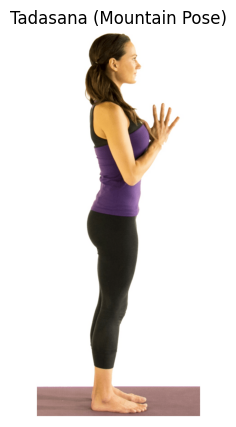


Difficulty
------------------------------------------------------------
Beginner

How to Perform
------------------------------------------------------------
1. Stand upright with your feet together or hip-width apart.
2. Distribute your weight evenly across both feet.
3. Keep your knees soft and avoid locking them.
4. Lengthen your spine and gently lift your chest.
5. Relax your shoulders away from your ears.
6. Keep your arms beside your body with palms facing forward.
7. Look straight ahead and breathe slowly.
8. Hold the pose for 20 to 30 seconds.

Common Mistakes
------------------------------------------------------------
✗ Locking the knees
✗ Lifting the shoulders
✗ Leaning forward or backward
✗ Holding the breath

Pose Benefits
------------------------------------------------------------
✓ Supports posture and body awareness
✓ Improves balance
✓ Strengthens the legs
✓ Encourages steady breathing

Recommended Duration
------------------------------------------------------------


Select an option (1, 2, or 3):  2



                 🧘 AI YOGA COACH
             Yoga for Health Conditions
1. ❤️ Cardiovascular Health
2. 🍎 Metabolic Health
0. Back to Main Menu



Select a health category number:  2



🍎 Metabolic Health
1. Obesity / Weight Management
2. Type 2 Diabetes
0. Back to Main Menu



Select a condition number:  2



                    🧘 AI YOGA COACH

🩺 Selected Health Condition
------------------------------------------------------------
Type 2 Diabetes

📂 Health Category
------------------------------------------------------------
🍎 Metabolic Health

🧘 Recommended Yoga Poses
------------------------------------------------------------
1. Bhujangasana (Cobra Pose)
2. Ardha Matsyendrasana (Half Lord of the Fishes Pose)
3. Paschimottanasana (Seated Forward Bend)
4. Savasana (Corpse Pose)
0. Skip Pose Guide



Select a pose to learn how to perform:  3



                 🧘 POSE GUIDE

Pose
------------------------------------------------------------
Paschimottanasana (Seated Forward Bend)
Selected pose: Paschimottanasana
Image path: /kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/paschimottanasana/140-0.png


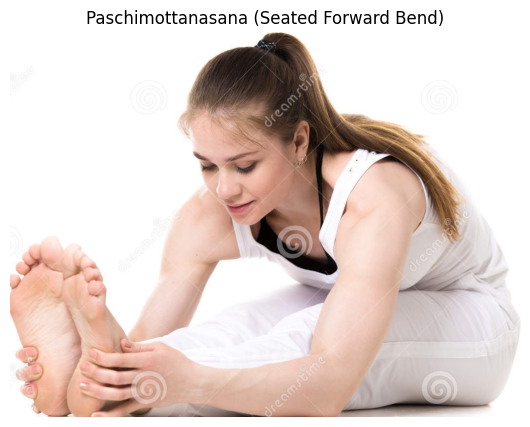


Difficulty
------------------------------------------------------------
Beginner

How to Perform
------------------------------------------------------------
1. Sit on the floor with both legs extended straight.
2. Keep your spine tall and shoulders relaxed.
3. Inhale and raise both arms overhead.
4. Exhale and hinge forward from your hips.
5. Reach for your feet, ankles, or shins without forcing.
6. Keep your knees slightly bent if needed.
7. Relax your neck and breathe steadily.
8. Slowly return to an upright seated position.

Common Mistakes
------------------------------------------------------------
✗ Rounding the back excessively
✗ Locking the knees
✗ Pulling forcefully on the feet
✗ Holding the breath

Pose Benefits
------------------------------------------------------------
✓ Stretches the hamstrings and spine
✓ Improves flexibility
✓ Calms the mind
✓ Supports healthy digestion

Recommended Duration
------------------------------------------------------------
Hold for 20–40 s


Select an option (1, 2, or 3):  2



                 🧘 AI YOGA COACH
             Yoga for Health Conditions
1. ❤️ Cardiovascular Health
2. 🍎 Metabolic Health
0. Back to Main Menu



Select a health category number:  2



🍎 Metabolic Health
1. Obesity / Weight Management
2. Type 2 Diabetes
0. Back to Main Menu



Select a condition number:  2



                    🧘 AI YOGA COACH

🩺 Selected Health Condition
------------------------------------------------------------
Type 2 Diabetes

📂 Health Category
------------------------------------------------------------
🍎 Metabolic Health

🧘 Recommended Yoga Poses
------------------------------------------------------------
1. Bhujangasana (Cobra Pose)
2. Ardha Matsyendrasana (Half Lord of the Fishes Pose)
3. Paschimottanasana (Seated Forward Bend)
4. Savasana (Corpse Pose)
0. Skip Pose Guide



Select a pose to learn how to perform:  4



                 🧘 POSE GUIDE

Pose
------------------------------------------------------------
Savasana (Corpse Pose)
Selected pose: Savasana
Image path: /kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/savasana/11. savasana_thought_bubbles_0.jpeg


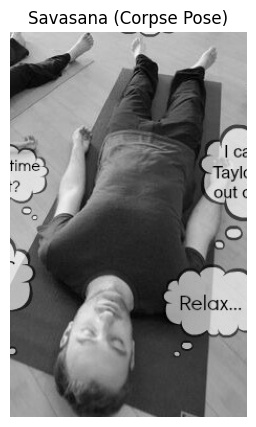


Difficulty
------------------------------------------------------------
Beginner

How to Perform
------------------------------------------------------------
1. Lie flat on your back on the mat.
2. Keep your legs slightly apart.
3. Relax your feet outward naturally.
4. Place your arms comfortably beside your body.
5. Turn your palms upward.
6. Close your eyes and relax your entire body.
7. Breathe naturally without controlling your breath.
8. Remain completely still and aware.

Common Mistakes
------------------------------------------------------------
✗ Keeping the body tense
✗ Holding the breath
✗ Keeping the shoulders raised
✗ Opening the eyes frequently

Pose Benefits
------------------------------------------------------------
✓ Relaxes the entire body
✓ Reduces stress and anxiety
✓ Calms the nervous system
✓ Promotes mental clarity

Recommended Duration
------------------------------------------------------------
Hold for 5–10 minutes.

🌿 Benefits
------------------------------

In [ ]:
def show_main_menu():

    while True:

        print("\n============================================================")
        print("                 🧘 AI YOGA COACH")
        print("============================================================")
        print("1. Wellness Goals")
        print("2. Yoga for Health Conditions")
        print("3. Exit")

        choice = input("\nSelect an option (1, 2, or 3): ").strip()

        if choice == "1":
            show_wellness_goals()

        elif choice == "2":
            show_health_categories()

        elif choice == "3":
            print("\n🙏 Thank you for using AI Yoga Coach!")
            break

        else:
            print("\n❌ Invalid choice.")


show_main_menu()

# AI Yoga Coach

This section connects the deep learning yoga pose classifier with personalized wellness guidance. The goal is to move beyond pose prediction and provide a user-centered yoga recommendation system.

The AI Yoga Coach workflow includes:

1. Predicting or selecting a yoga pose.
2. Selecting a wellness goal.
3. Recommending related poses.
4. Displaying a reference image.
5. Providing breathing guidance, benefits, precautions, step-by-step instructions, common mistakes, and a suggested follow-up pose.
   